In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
import requests
import tempfile
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


In [2]:

# Create an empty dataframe
data = pd.DataFrame(columns=['image_path', 'label'])

# Define the labels/classes

labels = {
    r"C:\Users\ARYAN\AI-edunet\Satellite Image data\cloudy": "Cloudy",
    r"C:\Users\ARYAN\AI-edunet\Satellite Image data\desert": "Desert",
    r"C:\Users\ARYAN\AI-edunet\Satellite Image data\green_area": "Green_Area",
    r"C:\Users\ARYAN\AI-edunet\Satellite Image data\water": "Water",
}


In [3]:
# Validate folder paths
for folder in labels:
    if not os.path.exists(folder):
        print(f"Warning: The folder {folder} does not exist.")
        continue

    # Process each image in the folder
    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        if os.path.isfile(image_path):  # Only process files
            label = labels[folder]
            data = pd.concat([data, pd.DataFrame({'image_path': [image_path], 'label': [label]})], ignore_index=True)


In [4]:
# Display the resulting DataFrame
print(data)


                                             image_path   label
0     C:\Users\ARYAN\AI-edunet\Satellite Image data\...  Cloudy
1     C:\Users\ARYAN\AI-edunet\Satellite Image data\...  Cloudy
2     C:\Users\ARYAN\AI-edunet\Satellite Image data\...  Cloudy
3     C:\Users\ARYAN\AI-edunet\Satellite Image data\...  Cloudy
4     C:\Users\ARYAN\AI-edunet\Satellite Image data\...  Cloudy
...                                                 ...     ...
2012  C:\Users\ARYAN\AI-edunet\Satellite Image data\...   Water
2013  C:\Users\ARYAN\AI-edunet\Satellite Image data\...   Water
2014  C:\Users\ARYAN\AI-edunet\Satellite Image data\...   Water
2015  C:\Users\ARYAN\AI-edunet\Satellite Image data\...   Water
2016  C:\Users\ARYAN\AI-edunet\Satellite Image data\...   Water

[2017 rows x 2 columns]


In [5]:
data.to_csv('image_dataset.csv', index=False)
df = pd.read_csv("image_dataset.csv")


In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   rotation_range=45,
                                   vertical_flip=True,
                                   fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(dataframe=train_df,
                                                    x_col="image_path",
                                                    y_col="label",
                                                    target_size=(255, 255),
                                                    batch_size=32,
                                                    class_mode="categorical")

test_generator = test_datagen.flow_from_dataframe(dataframe=test_df,
                                                  x_col="image_path",
                                                  y_col="label",
                                                  target_size=(255, 255),
                                                  batch_size=32,
                                                  class_mode="categorical")


Found 1613 validated image filenames belonging to 4 classes.
Found 404 validated image filenames belonging to 4 classes.


In [18]:
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(255, 255, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 253, 253, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 126, 126, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 124, 124, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,839,492 (56.61 MB)

 Trainable params: 14,839,492 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(train_generator, epochs=2, validation_data=test_generator)
num_samples = test_df.shape[0]
score = model.evaluate(test_generator, steps=num_samples//32+1)

Epoch 1/2
51/51 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6497 - loss: 0.7346 - val_accuracy: 0.7896 - val_loss: 0.4677
Epoch 2/2
51/51 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7756 - loss: 0.4952 - val_accuracy: 0.8144 - val_loss: 0.4045
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.8144 - loss: 0.4045


In [20]:
model.save('Modelenv.v1.h5')
model = load_model("Modelenv.v1.h5")
class_names = ['Cloudy', 'Desert', 'Green_Area', 'Water']

def plot_confusion_matrix(cm, classes):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 324ms/step


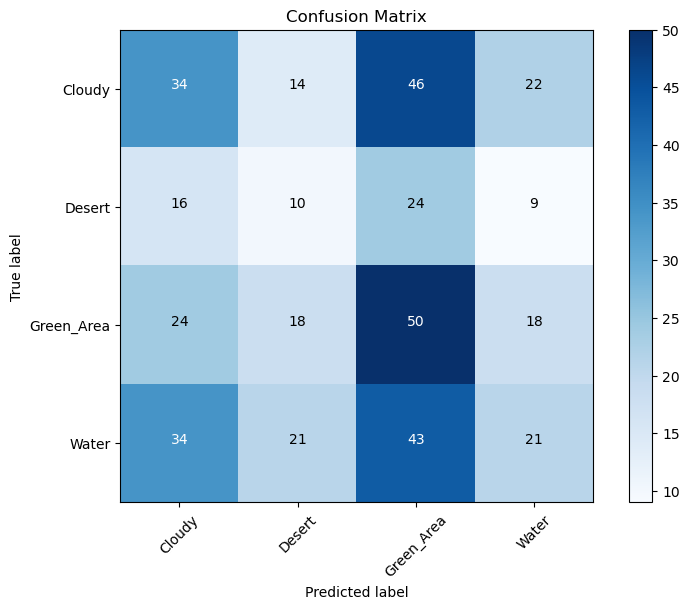

In [21]:
predictions = model.predict(test_generator)
actual_labels = test_generator.classes
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(actual_labels, predicted_labels)

plt.figure(figsize=(8, 6))
plot_confusion_matrix(cm, classes=class_names)
plt.show()


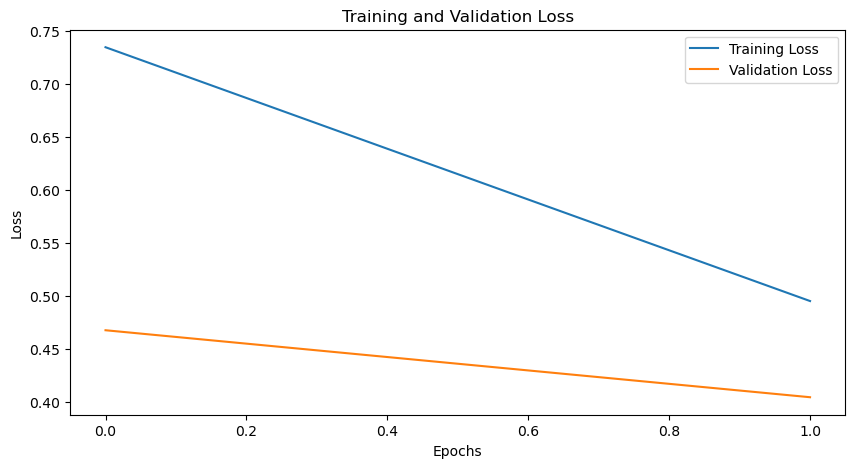

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


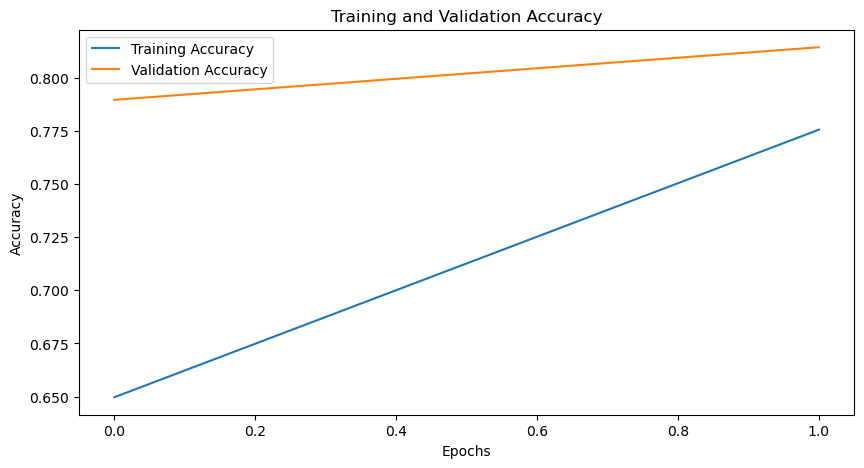

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
